Data Collection

In [ ]:
import pandas as pd

df = pd.read_csv("/content/bread basket.csv")
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


DATA PREPROCESSING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Transaction,0
Item,0
date_time,0
period_day,0
weekday_weekend,0


In [ ]:
#Distribusi ITEM
df['Item'].value_counts().head(10)

,count
Item,
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856
Sandwich,771
Medialuna,616
Hot chocolate,590
Cookies,540


In [ ]:
#transformasi datetime
df['date_time'] = pd.to_datetime(df['date_time'], format="%d-%m-%Y %H:%M")
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,2016-10-30 09:58:00,morning,weekend
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend
4,3,Jam,2016-10-30 10:07:00,morning,weekend


In [ ]:
#pisahkan tanggal
df['date'] = df['date_time'].dt.date

In [ ]:
#agregasi harian
#Data awal berupa transaksi per item diubah menjadi jumlah transaksi per hari.
daily = df.groupby('date').size().reset_index(name='jumlah_transaksi')
daily.head()

,date,jumlah_transaksi
0,2016-10-30,170
1,2016-10-31,199
2,2016-11-01,150
3,2016-11-02,164
4,2016-11-03,189


In [ ]:
daily['date'] = pd.to_datetime(daily['date'])

In [ ]:
df.isnull().sum()


,0
Transaction,0
Item,0
date_time,0
period_day,0
weekday_weekend,0
date,0


PEMBUATAN MODEL

In [ ]:
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month

In [ ]:
daily['lag_1'] = daily['jumlah_transaksi'].shift(1)         #jumlah penjualan H-1 (kemarin)
daily['lag_2'] = daily['jumlah_transaksi'].shift(2)         #jumlah penjualan H-2 (2 hari yang lalu)
daily['ma_3'] = daily['jumlah_transaksi'].rolling(3).mean() #Moving Average 3 hari (rata-rata 3 hari terakhir)

In [ ]:
daily = daily.dropna()
daily.head()

,date,jumlah_transaksi,day_of_week,month,lag_1,lag_2,ma_3
4,2016-11-03,189,3,11,164.0,150.0,167.666667
5,2016-11-04,187,4,11,189.0,164.0,180.000000
6,2016-11-05,275,5,11,187.0,189.0,217.000000
7,2016-11-06,197,6,11,275.0,187.0,219.666667
8,2016-11-07,148,0,11,197.0,275.0,206.666667


In [ ]:
#split data
from sklearn.model_selection import train_test_split

X = daily[['lag_1','lag_2','day_of_week','month','ma_3']]
y = daily['jumlah_transaksi']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
#training model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# INTERPRETASI OTOMATIS
print("\nInterpretasi Model:")

# MAE
if mae < 10:
    print("- MAE: Sangat baik")
elif mae < 20:
    print("- MAE: Baik")
else:
    print("- MAE: Kurang baik")

# RMSE
if rmse < 15:
    print("- RMSE: Sangat baik")
elif rmse < 25:
    print("- RMSE: baik")
else:
    print("- RMSE: Kurang baik")

# R2
if r2 > 0.8:
    print("- R2: Sangat baik)")
elif r2 > 0.6:
    print("- R2: Baik ")
elif r2 > 0.4:
    print("- R2: Cukup")
else:
    print("- R2: Kurang baik")

MAE: 13.018387096774193
RMSE: 17.569872950134584
R2: 0.790889629599868

Interpretasi Model:
- MAE: Baik
- RMSE: baik
- R2: Baik 


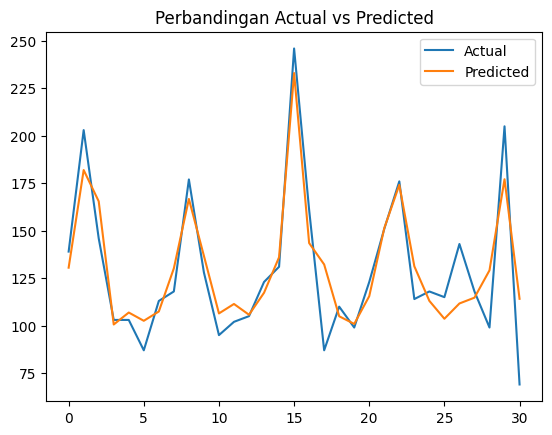

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Perbandingan Actual vs Predicted")
plt.show()

In [ ]:
import joblib
joblib.dump(model, "model_bakery.pkl")

['model_bakery.pkl']

In [ ]:
import pandas as pd

input_data = pd.DataFrame({
    'lag_1':[120],
    'lag_2':[110],
    'day_of_week':[2],
    'month':[11],
    'ma_3':[115]
})

pred = model.predict(input_data)
hasil = max(0, round(pred[0]))

print("Rekomendasi produksi:", hasil)

Rekomendasi produksi: 103
